<a href="https://colab.research.google.com/github/ggvignesh/Google-Colab-Projects/blob/main/EXPLORATORY_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional but useful
!pip install missingno
import missingno as msno

# Set styles
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [ ]:
# Step 2: Load Dataset
from google.colab import files
uploaded = files.upload()  # Upload netflix_titles.csv here

# Load the CSV
df = pd.read_csv('netflix_titles.csv')

# Display first few rows
df.head()


Saving netflix_titles.csv to netflix_titles.csv


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Rows: 8807, Columns: 12
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


<Axes: >

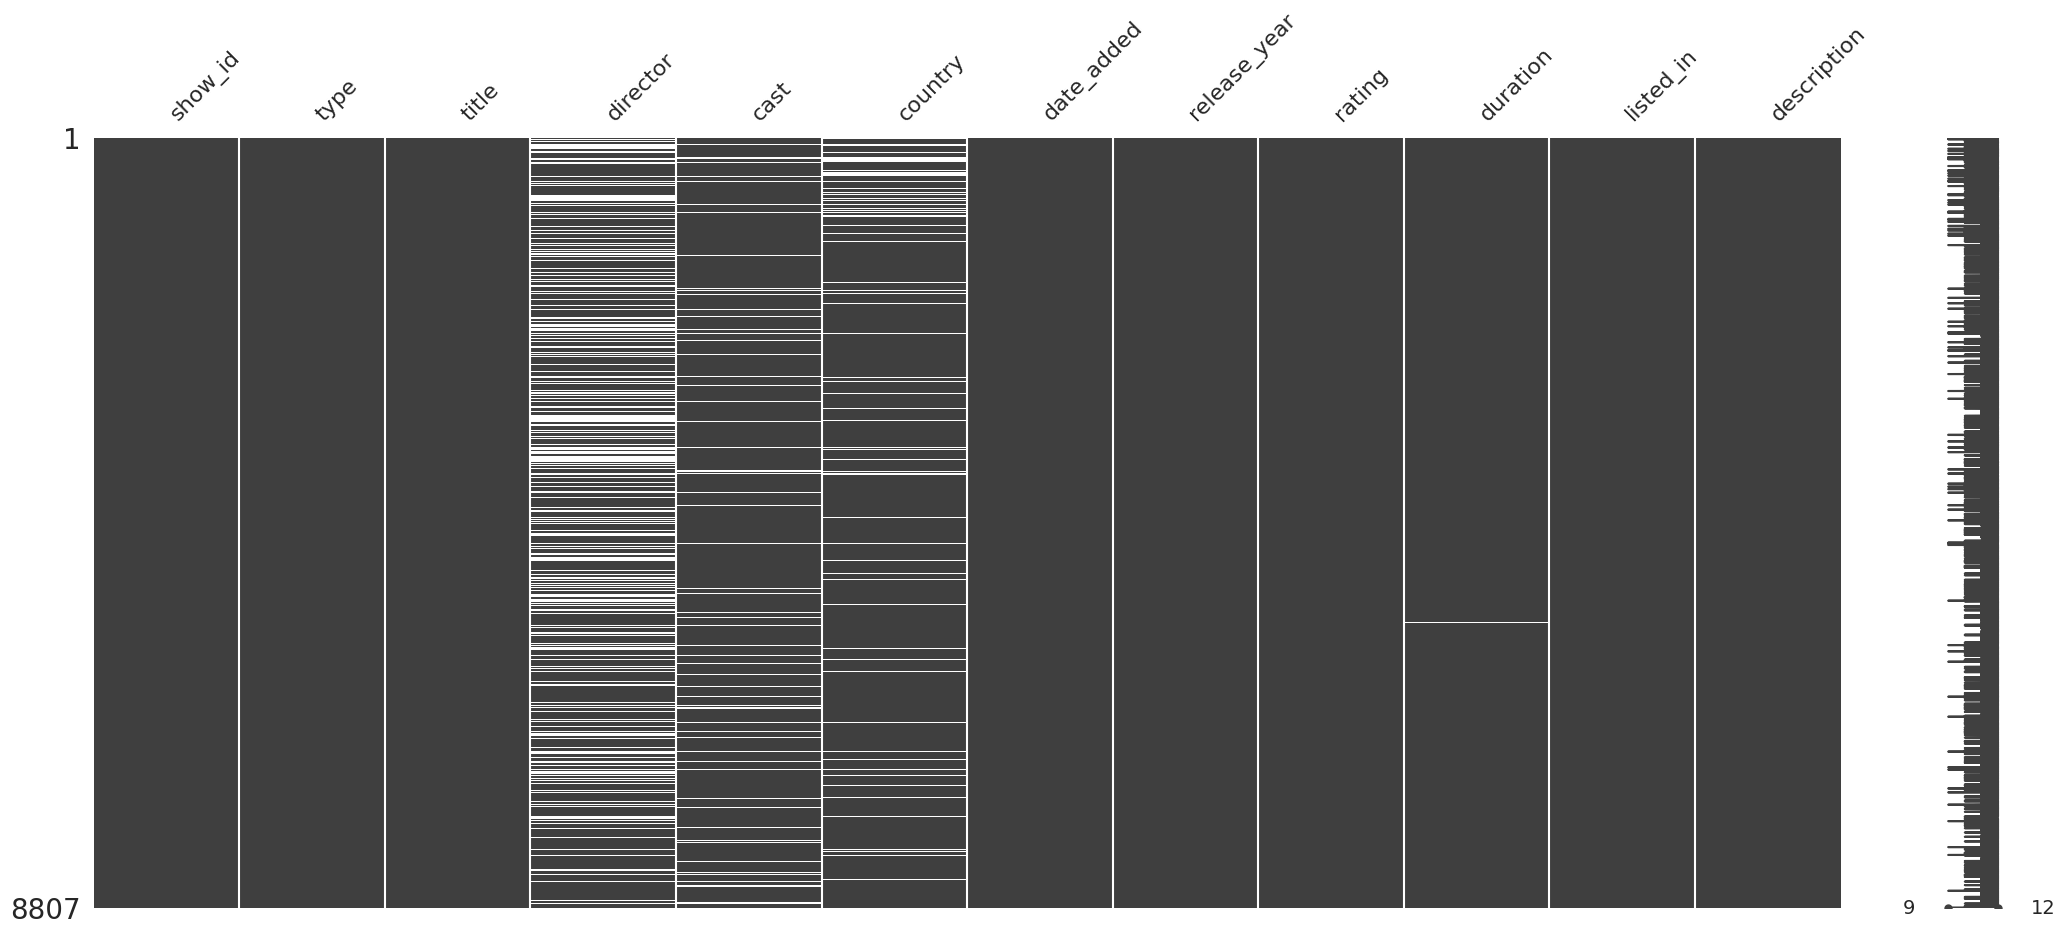

In [ ]:
# Shape of the dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Column names
print(df.columns)

# Data types
print(df.dtypes)

# Missing values
df.isnull().sum()

# Visualize missing values
msno.matrix(df)


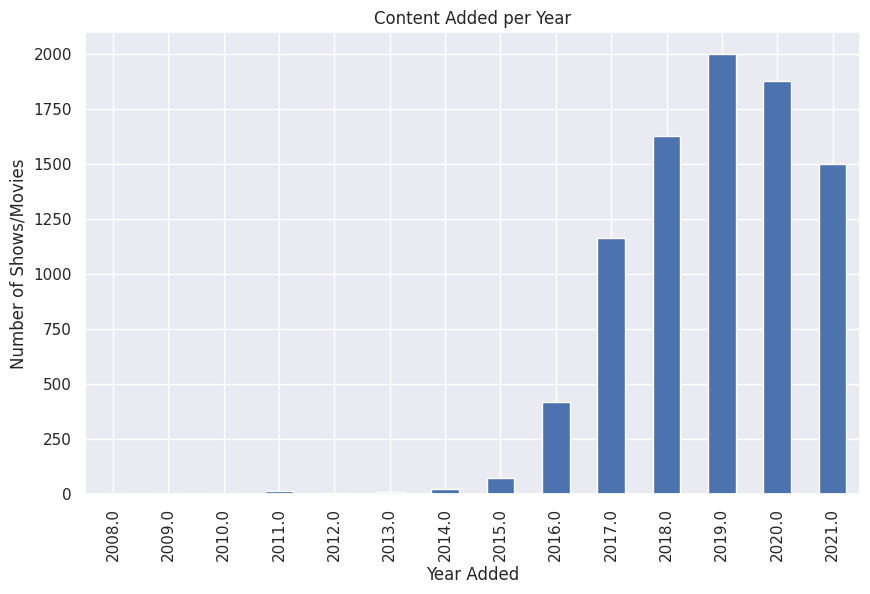

In [ ]:
# Safely convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year after handling invalid/missing formats
df['year_added'] = df['date_added'].dt.year

# Plot content added per year
df['year_added'].value_counts().sort_index().plot(kind='bar', title='Content Added per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Shows/Movies')
plt.show()

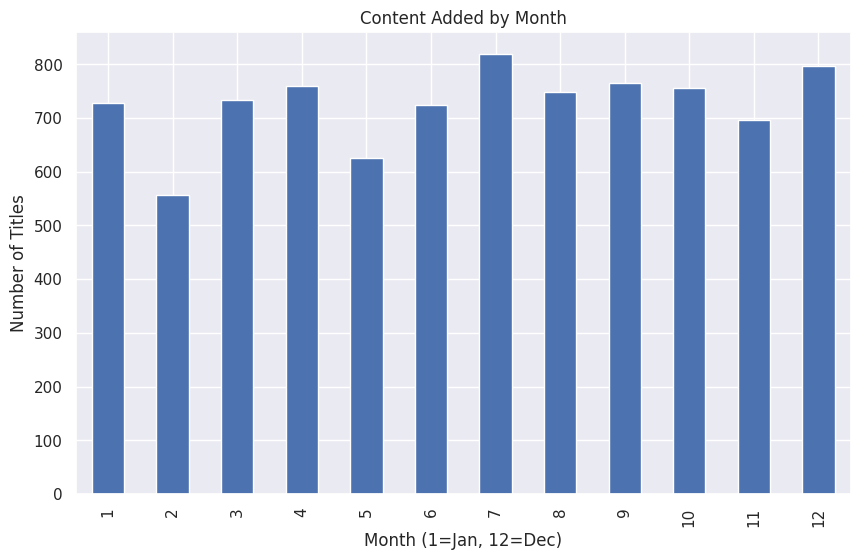

In [ ]:
# Extract month from 'date_added'
df['month_added'] = df['date_added'].dt.month

# Plot: Content added by month
month_order = range(1, 13)
df['month_added'].value_counts().reindex(month_order).plot(kind='bar')
plt.title("Content Added by Month")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Number of Titles")
plt.show()


In [ ]:
# Group by year and count number of titles added
yearly_content = df['year_added'].value_counts().sort_index()

# Convert to DataFrame
content_ts = pd.DataFrame({
    'year': yearly_content.index,
    'count': yearly_content.values
})

content_ts = content_ts.set_index('year')


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-1257650040.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(start='2000', periods=5, freq='5Y')  # Every 5 years till 2030


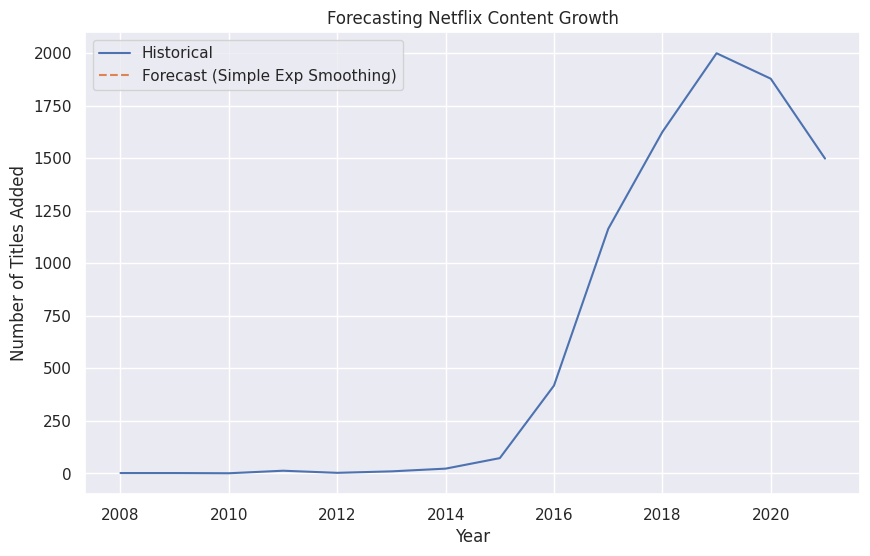

In [ ]:
from statsmodels.tsa.api import SimpleExpSmoothing
import pandas as pd
import matplotlib.pyplot as plt

# Convert index to datetime if not already
content_ts.index = pd.to_datetime(content_ts.index, format='%Y')

# Fit the model
model = SimpleExpSmoothing(content_ts['count']).fit(smoothing_level=0.5, optimized=False)

# Create future years as datetime
future_dates = pd.date_range(start='2000', periods=5, freq='5Y')  # Every 5 years till 2030
forecast = pd.Series(model.forecast(5), index=future_dates)

# Plot everything
plt.figure(figsize=(10,6))
plt.plot(content_ts, label='Historical')
plt.plot(forecast, label='Forecast (Simple Exp Smoothing)', linestyle='--')
plt.title("Forecasting Netflix Content Growth")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class DataProfiler:
    def __init__(self, filepath):
        self.df = pd.read_csv(filepath)
        self.filepath = filepath
        print(f"✅ Loaded dataset: {filepath}")

    def preview(self, n=5):
        display(self.df.head(n))

    def info(self):
        print("\n📄 Basic Info:")
        print(self.df.info())

    def null_summary(self):
        print("\n🔍 Missing Values:")
        print(self.df.isnull().sum())

    def visualize_distributions(self):
        print("\n📊 Distributions for Categorical Columns:")
        cat_cols = self.df.select_dtypes(include='object').columns
        for col in cat_cols:
            if self.df[col].nunique() < 50:
                plt.figure(figsize=(10,4))
                sns.countplot(y=col, data=self.df, order=self.df[col].value_counts().index[:10])
                plt.title(f"Distribution of {col}")
                plt.show()

    def numeric_summary(self):
        print("\n📈 Summary Stats for Numeric Columns:")
        display(self.df.describe())

    def auto_date_column_detection(self):
        for col in self.df.columns:
            try:
                self.df[col] = pd.to_datetime(self.df[col])
                print(f"🗓️ Converted {col} to datetime.")
            except:
                pass


In [ ]:
import ipywidgets as widgets
from IPython.display import display

type_selector = widgets.Dropdown(
    options=['All'] + df['type'].unique().tolist(),
    value='All',
    description='Type:',
)

def update_graph(content_type):
    if content_type == 'All':
        filtered = df
    else:
        filtered = df[df['type'] == content_type]

    sns.countplot(y='rating', data=filtered, order=filtered['rating'].value_counts().index[:10])
    plt.title(f"Rating Distribution ({content_type})")
    plt.show()

widgets.interact(update_graph, content_type=type_selector)


interactive(children=(Dropdown(description='Type:', options=('All', 'Movie', 'TV Show'), value='All'), Output(…

<function __main__.update_graph(content_type)>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_ml = df[['type', 'release_year', 'duration', 'rating']].dropna()

# Convert duration to numeric if possible
df_ml['duration'] = df_ml['duration'].str.extract('(\d+)').astype(float)

# Encode categorical
le_type = LabelEncoder()
le_rating = LabelEncoder()

df_ml['type_enc'] = le_type.fit_transform(df_ml['type'])
df_ml['rating_enc'] = le_rating.fit_transform(df_ml['rating'])

X = df_ml[['type_enc', 'release_year', 'duration']]
y = df_ml['rating_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1816189610.py:8: SyntaxWarning: invalid escape sequence '\d'
  df_ml['duration'] = df_ml['duration'].str.extract('(\d+)').astype(float)


Accuracy: 0.3806818181818182


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-987953882.py:9: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  holt_model = Holt(content_ts['count']).fit(smoothing_level=0.8, smoothing_slope=0.2, optimized=False)
/tmp/ipython-input-987953882.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(start='2021', periods=5, freq='2Y')


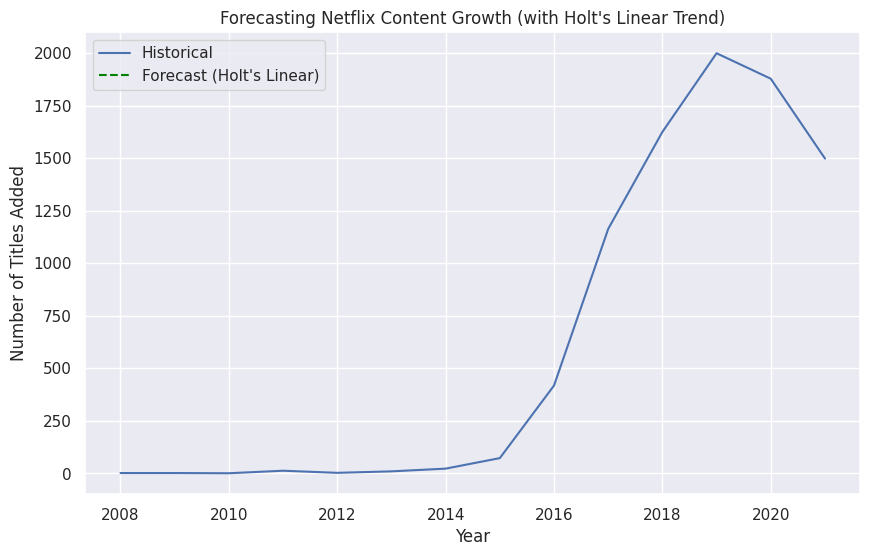

In [ ]:
from statsmodels.tsa.holtwinters import Holt
import pandas as pd
import matplotlib.pyplot as plt

# Make sure index is datetime (if not already)
content_ts.index = pd.to_datetime(content_ts.index, format='%Y')

# Fit Holt's Linear Trend model
holt_model = Holt(content_ts['count']).fit(smoothing_level=0.8, smoothing_slope=0.2, optimized=False)

# Forecast next 5 future points (every 2 years till 2030)
future_dates = pd.date_range(start='2021', periods=5, freq='2Y')
holt_forecast = pd.Series(holt_model.forecast(5), index=future_dates)

# Plot
plt.figure(figsize=(10,6))
plt.plot(content_ts, label='Historical')
plt.plot(holt_forecast, label="Forecast (Holt's Linear)", linestyle='--', color='green')
plt.title("Forecasting Netflix Content Growth (with Holt's Linear Trend)")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-701511914.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  holt_model = Holt(content_ts['count']).fit(smoothing_level=0.8, smoothing_slope=0.2, optimized=False)
/tmp/ipython-input-701511914.py:9: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(start='2021', periods=5, freq='2Y')


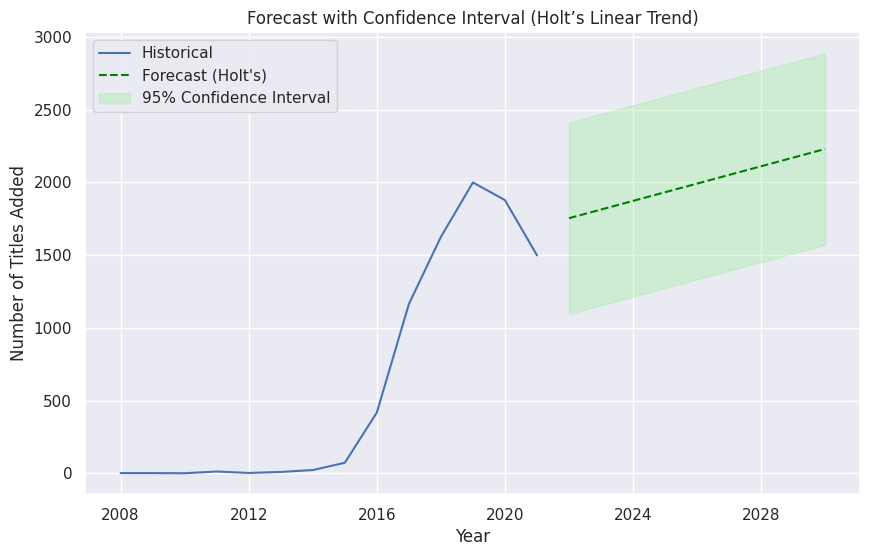

In [ ]:
from statsmodels.tsa.holtwinters import Holt
import numpy as np
import matplotlib.pyplot as plt

# Fit Holt's Linear Trend Model
holt_model = Holt(content_ts['count']).fit(smoothing_level=0.8, smoothing_slope=0.2, optimized=False)

# Forecast future
future_dates = pd.date_range(start='2021', periods=5, freq='2Y')
forecast = holt_model.forecast(5)
forecast.index = future_dates

# Calculate residuals (errors between real and fitted values)
residuals = content_ts['count'] - holt_model.fittedvalues
std_dev = residuals.std()

# Create confidence interval (95% = ±1.96 * std deviation)
ci_upper = forecast + 1.96 * std_dev
ci_lower = forecast - 1.96 * std_dev

# Plot forecast with confidence intervals
plt.figure(figsize=(10,6))
plt.plot(content_ts, label='Historical')
plt.plot(forecast, label="Forecast (Holt's)", linestyle='--', color='green')
plt.fill_between(forecast.index, ci_lower, ci_upper, color='lightgreen', alpha=0.3, label='95% Confidence Interval')
plt.title("Forecast with Confidence Interval (Holt’s Linear Trend)")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# Get fitted values from model (predictions on historical data)
fitted_values = holt_model.fittedvalues

# True values
true_values = content_ts['count']

# MAPE (as a percentage)
mape = mean_absolute_percentage_error(true_values, fitted_values) * 100

# RMSE
rmse = np.sqrt(mean_squared_error(true_values, fitted_values))

print(f"📊 MAPE: {mape:.2f}%")
print(f"📊 RMSE: {rmse:.2f}")


📊 MAPE: 66.06%
📊 RMSE: 327.65


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# -------------------------
# Function 1: EDA Function
# -------------------------
def perform_eda(df):
    print("🔍 EDA Summary:")

    # Convert date and extract year/month
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year_added'] = df['date_added'].dt.year
    df['month_added'] = df['date_added'].dt.month

    print(f"\n🧾 Dataset Shape: {df.shape}")
    print(f"\n🧾 Missing Values:\n{df.isnull().sum()}")

    print("\n📊 Count of Content Types:")
    sns.countplot(data=df, x='type')
    plt.title("Type of Content")
    plt.show()

    print("\n🌍 Top 10 Countries with Most Content:")
    df['country'].value_counts().head(10).plot(kind='barh', color='skyblue')
    plt.title("Top 10 Countries")
    plt.xlabel("Number of Titles")
    plt.show()

    print("\n📅 Content Added Per Year:")
    df['year_added'].value_counts().sort_index().plot(kind='bar', color='lightcoral')
    plt.title("Titles Added by Year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

    return df

In [ ]:
def run_forecast(ts_series, forecast_years=5, model='holt'):
    print(f"\n🔮 Running Forecast using: {model.upper()} Model")

    # Fit model
    if model == 'holt':
        fit_model = Holt(ts_series).fit(smoothing_level=0.8, smoothing_slope=0.2, optimized=False)
    elif model == 'ses':
        fit_model = SimpleExpSmoothing(ts_series).fit(smoothing_level=0.5, optimized=False)
    else:
        raise ValueError("Invalid model. Use 'holt' or 'ses'.")

    # Forecast future
    last_year = ts_series.index[-1]
    future_years = [last_year + 2*i for i in range(1, forecast_years+1)]
    forecast = pd.Series(fit_model.forecast(forecast_years), index=future_years)

    # Residuals and Confidence Interval
    residuals = ts_series - fit_model.fittedvalues
    std_dev = residuals.std()
    ci_upper = forecast + 1.96 * std_dev
    ci_lower = forecast - 1.96 * std_dev

    # Plot
    plt.figure(figsize=(10,6))
    plt.plot(ts_series, label='Historical')
    plt.plot(forecast, label=f'{model.upper()} Forecast', linestyle='--', color='darkgreen')
    plt.fill_between(forecast.index, ci_lower, ci_upper, color='lightgreen', alpha=0.3, label='95% CI')
    plt.title("Content Forecast with Confidence Interval")
    plt.xlabel("Year")
    plt.ylabel("Number of Titles Added")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Metrics
    mape = mean_absolute_percentage_error(ts_series, fit_model.fittedvalues) * 100
    rmse = np.sqrt(mean_squared_error(ts_series, fit_model.fittedvalues))
    print(f"\n📏 MAPE: {mape:.2f}%")
    print(f"📏 RMSE: {rmse:.2f}")

    return forecast, ci_upper, ci_lower

🔍 EDA Summary:

🧾 Dataset Shape: (8807, 14)

🧾 Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added        98
month_added       98
dtype: int64

📊 Count of Content Types:


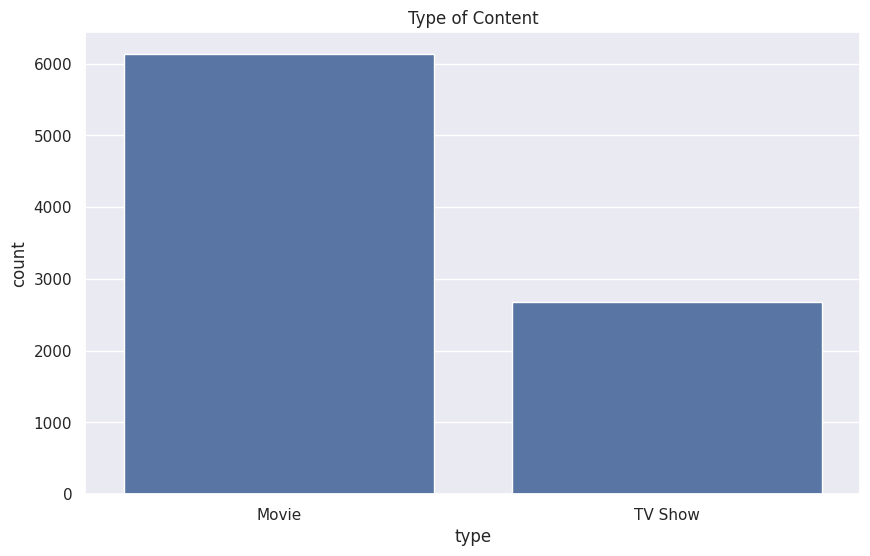


🌍 Top 10 Countries with Most Content:


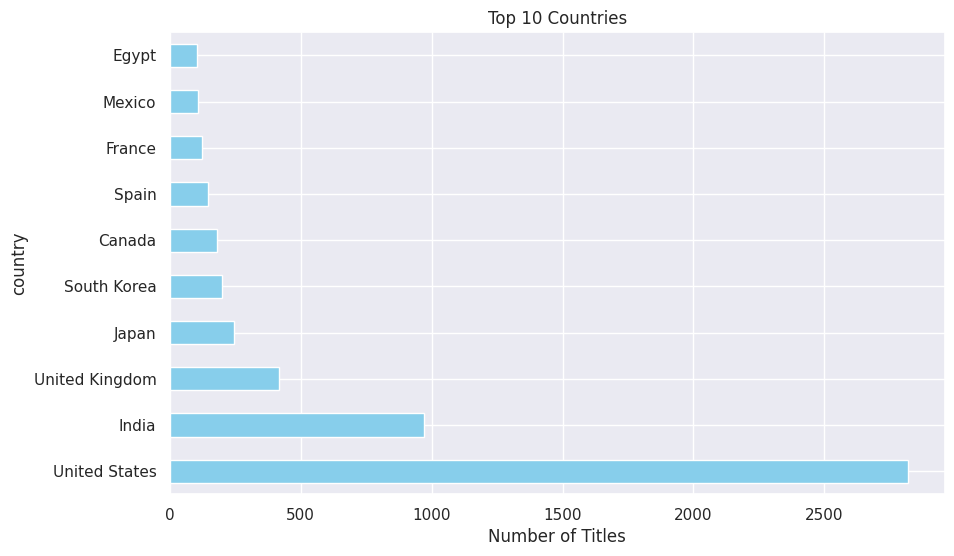


📅 Content Added Per Year:


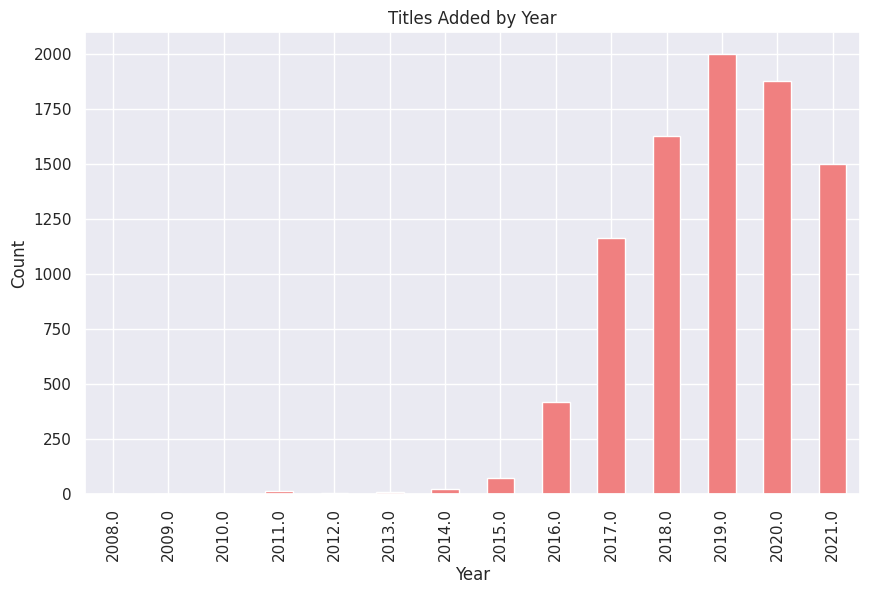


🔮 Running Forecast using: HOLT Model


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/tmp/ipython-input-2213809857.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit_model = Holt(ts_series).fit(smoothing_level=0.8, smoothing_slope=0.2, optimized=False)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


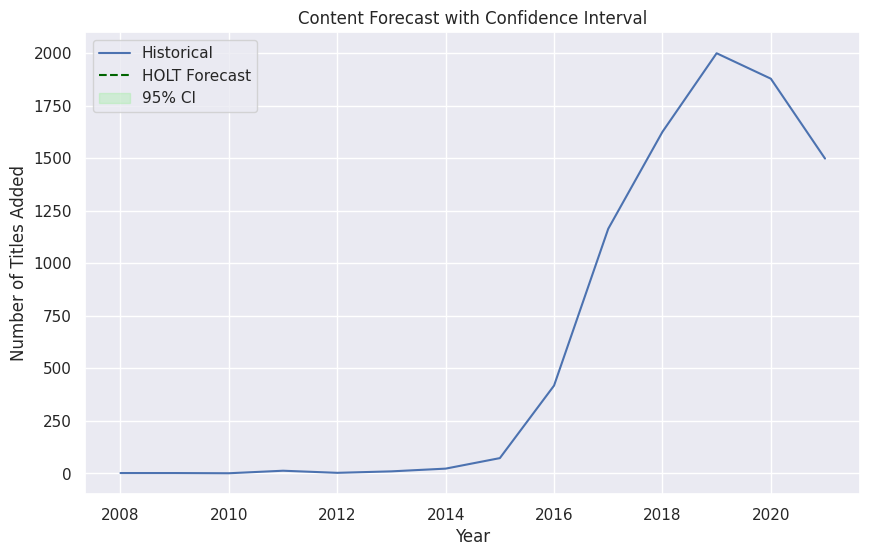


📏 MAPE: 66.06%
📏 RMSE: 327.65


In [ ]:
# Load Netflix data
df = pd.read_csv('/content/netflix_titles.csv')

# Run EDA
df = perform_eda(df)

# Create time series for forecasting
content_ts = df['year_added'].value_counts().sort_index()
content_ts = content_ts.loc[content_ts.index.notnull()]
content_ts = content_ts.astype(int)
content_ts.index = content_ts.index.astype(int)

# Run forecast
forecast, upper_ci, lower_ci = run_forecast(content_ts, forecast_years=5, model='holt')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Function to Analyze Genre Trends Over Time
def genre_trend_analysis(df):
    """
    Analyzes how different genres have trended over the years.
    Produces a heatmap of top genres by year.
    """
    # Drop rows with missing genres or date_added
    df = df.dropna(subset=['listed_in', 'date_added'])

    # Convert date to datetime and extract year
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year_added'] = df['date_added'].dt.year

    # Split multiple genres into separate rows
    genre_df = df[['show_id', 'listed_in', 'year_added']].copy()
    genre_df['listed_in'] = genre_df['listed_in'].str.split(', ')
    exploded = genre_df.explode('listed_in')

    # Group by year and genre
    genre_counts = exploded.groupby(['year_added', 'listed_in']).size().reset_index(name='count')

    # Pivot for heatmap
    pivot = genre_counts.pivot(index='year_added', columns='listed_in', values='count').fillna(0)

    # Filter top 10 genres
    top_genres = pivot.sum().sort_values(ascending=False).head(10).index
    top_pivot = pivot[top_genres]

    # Plot heatmap
    plt.figure(figsize=(14, 6))
    sns.heatmap(top_pivot, cmap='YlOrRd', annot=True, fmt=".0f", linewidths=0.5)
    plt.title("🎬 Top 10 Genre Trends Over Time")
    plt.xlabel("Genre")
    plt.ylabel("Year Added")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return top_pivot.tail(10)  # Return last 10 years for reference


/tmp/ipython-input-2932724710.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
/tmp/ipython-input-2932724710.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_added'] = df['date_added'].dt.year
/tmp/ipython-input-2932724710.py:40: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1279

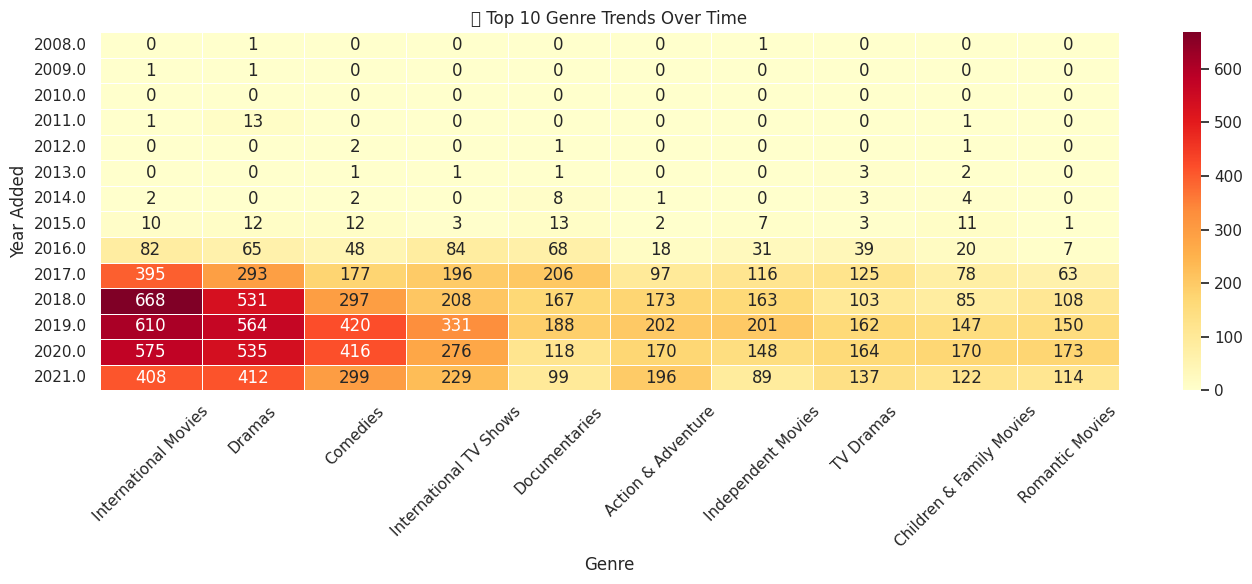

listed_in,International Movies,Dramas,Comedies,International TV Shows,Documentaries,Action & Adventure,Independent Movies,TV Dramas,Children & Family Movies,Romantic Movies
year_added,,,,,,,,,,
2012.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2013.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,3.0,2.0,0.0
2014.0,2.0,0.0,2.0,0.0,8.0,1.0,0.0,3.0,4.0,0.0
2015.0,10.0,12.0,12.0,3.0,13.0,2.0,7.0,3.0,11.0,1.0
2016.0,82.0,65.0,48.0,84.0,68.0,18.0,31.0,39.0,20.0,7.0
2017.0,395.0,293.0,177.0,196.0,206.0,97.0,116.0,125.0,78.0,63.0
2018.0,668.0,531.0,297.0,208.0,167.0,173.0,163.0,103.0,85.0,108.0
2019.0,610.0,564.0,420.0,331.0,188.0,202.0,201.0,162.0,147.0,150.0
2020.0,575.0,535.0,416.0,276.0,118.0,170.0,148.0,164.0,170.0,173.0


In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')
genre_trend_analysis(df)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Function: Clustering-Based Recommendation
def clustering_recommendation(df, n_clusters=5):
    """
    Clusters Netflix titles using KMeans based on duration, rating, type, and genre.
    Returns a t-SNE plot of clusters and top entries per cluster.
    """

    # Drop rows with missing key values
    df = df.dropna(subset=['type', 'duration', 'rating', 'listed_in'])

    # Parse durations into minutes
    def parse_duration(x):
        try:
            if 'min' in x:
                return int(x.replace(' min', ''))
            elif 'Season' in x:
                return int(x.split(' ')[0]) * 60
            else:
                return 0
        except:
            return 0

    df['duration_cleaned'] = df['duration'].apply(parse_duration)

    # Extract primary genre
    df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

    # Encode categorical features
    df['type_encoded'] = LabelEncoder().fit_transform(df['type'])
    df['genre_encoded'] = LabelEncoder().fit_transform(df['primary_genre'])
    df['rating_encoded'] = LabelEncoder().fit_transform(df['rating'])

    # Feature matrix
    features = df[['duration_cleaned', 'type_encoded', 'genre_encoded', 'rating_encoded']]

    # Normalize
    scaled = StandardScaler().fit_transform(features)

    # Clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    df['cluster'] = kmeans.fit_predict(scaled)

    # t-SNE for visualization
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(scaled)
    df['x'] = reduced[:, 0]
    df['y'] = reduced[:, 1]

    # Plot clusters
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='x', y='y', hue='cluster', palette='Set2')
    plt.title("🎯 Clustering of Netflix Titles (KMeans + t-SNE)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

    return df[['title', 'type', 'primary_genre', 'rating', 'duration', 'cluster']].head(10)


/tmp/ipython-input-1599654776.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_cleaned'] = df['duration'].apply(parse_duration)
/tmp/ipython-input-1599654776.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()
/tmp/ipython-input-1599654776.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

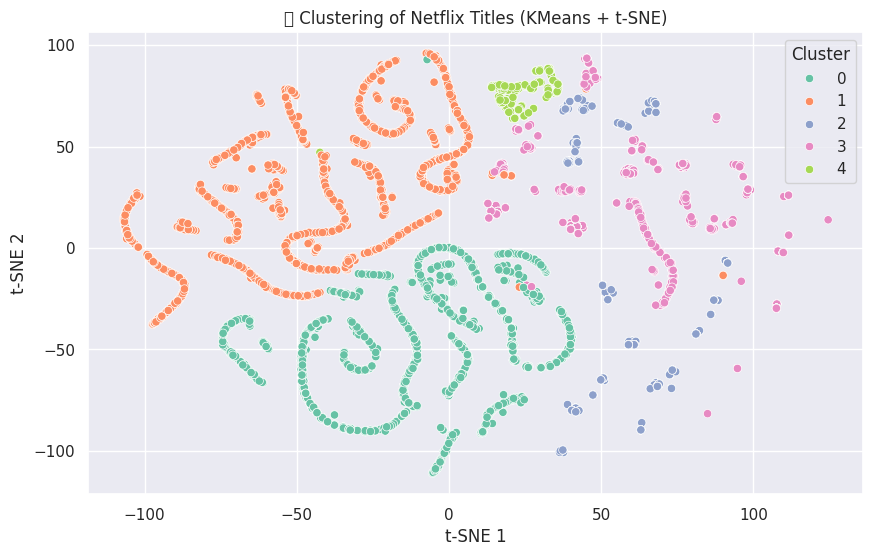

,title,type,primary_genre,rating,duration,cluster
0,Dick Johnson Is Dead,Movie,Documentaries,PG-13,90 min,1
1,Blood & Water,TV Show,International TV Shows,TV-MA,2 Seasons,3
2,Ganglands,TV Show,Crime TV Shows,TV-MA,1 Season,2
3,Jailbirds New Orleans,TV Show,Docuseries,TV-MA,1 Season,2
4,Kota Factory,TV Show,International TV Shows,TV-MA,2 Seasons,3
5,Midnight Mass,TV Show,TV Dramas,TV-MA,1 Season,3
6,My Little Pony: A New Generation,Movie,Children & Family Movies,PG,91 min,1
7,Sankofa,Movie,Dramas,TV-MA,125 min,0
8,The Great British Baking Show,TV Show,British TV Shows,TV-14,9 Seasons,4
9,The Starling,Movie,Comedies,PG-13,104 min,1


In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')
clustering_recommendation(df, n_clusters=5)


In [ ]:
import pandas as pd
import plotly.express as px

# ✅ Function to Plot Geo Heatmap
def geo_visualization(df):
    """
    Creates an interactive geo heatmap showing the number of Netflix titles produced per country.
    Uses Plotly choropleth for visualization.
    """

    # Drop missing countries and separate multiple countries per row
    df = df.dropna(subset=['country'])
    df['country'] = df['country'].str.split(', ')
    exploded = df.explode('country')

    # Count titles per country
    country_counts = exploded['country'].value_counts().reset_index()
    country_counts.columns = ['country', 'count']

    # Plot using Plotly
    fig = px.choropleth(
        country_counts,
        locations='country',
        locationmode='country names',
        color='count',
        hover_name='country',
        color_continuous_scale='Reds',
        title='🌍 Netflix Content Count by Country'
    )

    fig.update_geos(showframe=False, showcoastlines=True)
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
    fig.show()

    return country_counts.head(10)


In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')
geo_visualization(df)


/tmp/ipython-input-132927604.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['country'] = df['country'].str.split(', ')


,country,count
0,United States,3689
1,India,1046
2,United Kingdom,804
3,Canada,445
4,France,393
5,Japan,318
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
import seaborn as sns

# Download NLTK stopwords if not already
nltk.download('stopwords')
from nltk.corpus import stopwords

# ✅ Function: NLP Analysis
def nlp_analysis(df):
    """
    Analyzes Netflix 'description' field using:
    - WordCloud for visualizing common words
    - TF-IDF for top keywords
    """

    # Drop null descriptions
    df = df.dropna(subset=['description'])

    # Combine all descriptions into one string
    text_data = " ".join(df['description'].astype(str).tolist())

    # Set stopwords
    stop_words = set(stopwords.words('english'))

    # WordCloud
    wordcloud = WordCloud(
        stopwords=stop_words,
        background_color='white',
        max_words=100,
        width=800,
        height=400
    ).generate(text_data)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("🧠 WordCloud of Netflix Descriptions")
    plt.show()

    # TF-IDF Vectorizer
    vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
    tfidf_matrix = vectorizer.fit_transform(df['description'].astype(str))
    tfidf_scores = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
    top_keywords = tfidf_scores.sum().sort_values(ascending=False)

    # Barplot of TF-IDF keywords
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='coolwarm')
    plt.title("🔍 Top Keywords in Netflix Descriptions (TF-IDF)")
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Keyword")
    plt.show()

    return top_keywords.head(10)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.



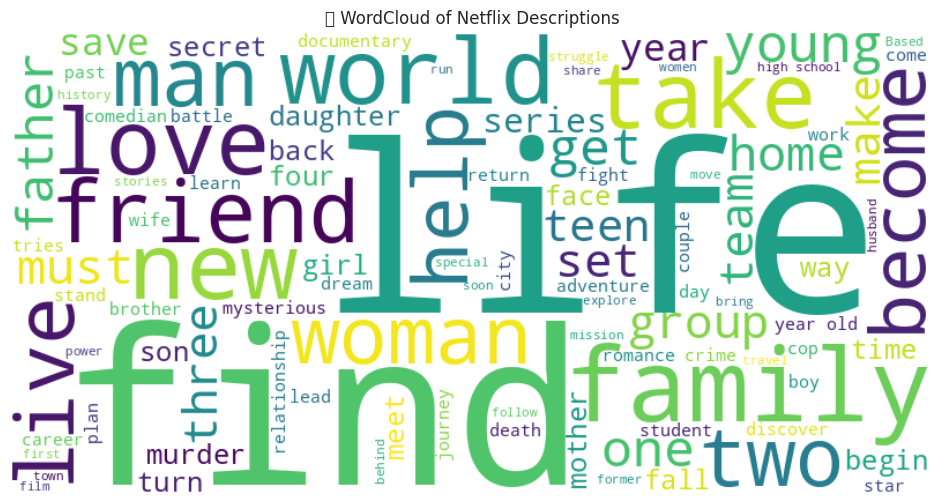

/tmp/ipython-input-3946958897.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



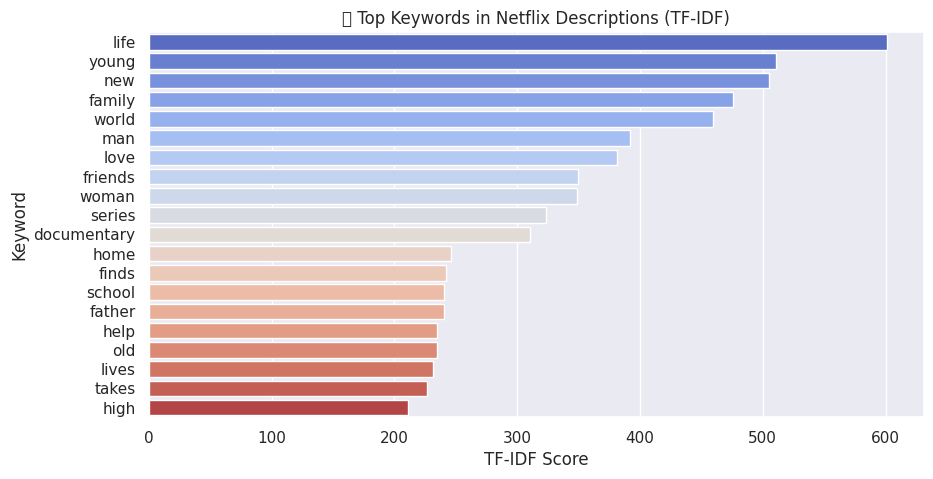

,0
life,601.063224
young,511.085030
new,505.109235
family,475.892917
world,459.092648
man,391.741088
love,381.078961
friends,349.506775
woman,348.698053
series,323.363870


In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')
nlp_analysis(df)


In [ ]:
from statsmodels.tsa.api import SimpleExpSmoothing
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def full_eda_dashboard(df):
    # 1. Basic Info
    print("📄 Basic Info:\n")
    print("Shape:", df.shape)
    print("Missing values:\n", df.isnull().sum())
    display(df.head(5))

    # 2. Content Per Year
    print("\n📊 Titles Added Per Year:")
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year_added'] = df['date_added'].dt.year
    content_by_year = df['year_added'].value_counts().sort_index()

    plt.figure(figsize=(12, 5))
    content_by_year.plot(kind='bar', color='skyblue')
    plt.title("Number of Titles Added Each Year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.grid(axis='y')
    plt.show()

        # 3. Forecasting
    print("\n📈 Forecast (Simple Exponential Smoothing):")
    ts = content_by_year.dropna()
    model = SimpleExpSmoothing(ts).fit(smoothing_level=0.6, optimized=False)

    # Create future index as integers
    last_year = int(ts.index.max())
    forecast_years = list(range(last_year + 2, last_year + 12, 2))  # 5 future values

    forecast_values = model.forecast(len(forecast_years))
    forecast_series = pd.Series(forecast_values.values, index=forecast_years)

    plt.figure(figsize=(10, 5))
    ts.plot(label='Historical')
    forecast_series.plot(label='Forecast', linestyle='--')
    plt.title("Forecasting Titles Growth (Next 10 Years)")
    plt.xlabel("Year")
    plt.ylabel("Titles")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 4. WordCloud
    print("\n☁️ WordCloud from Descriptions:")
    desc = " ".join(df['description'].dropna().astype(str).tolist())
    wordcloud = WordCloud(stopwords='english', background_color='white', width=800, height=400).generate(desc)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Most Common Words in Descriptions")
    plt.show()

    # 5. TF-IDF Keywords
    print("\n🔍 Top Keywords by TF-IDF:")
    tfidf = TfidfVectorizer(stop_words='english', max_features=10)
    tfidf_matrix = tfidf.fit_transform(df['description'].dropna())
    scores = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
    print(scores.sum().sort_values(ascending=False).head(10))


📄 Basic Info:

Shape: (8807, 12)
Missing values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



📊 Titles Added Per Year:


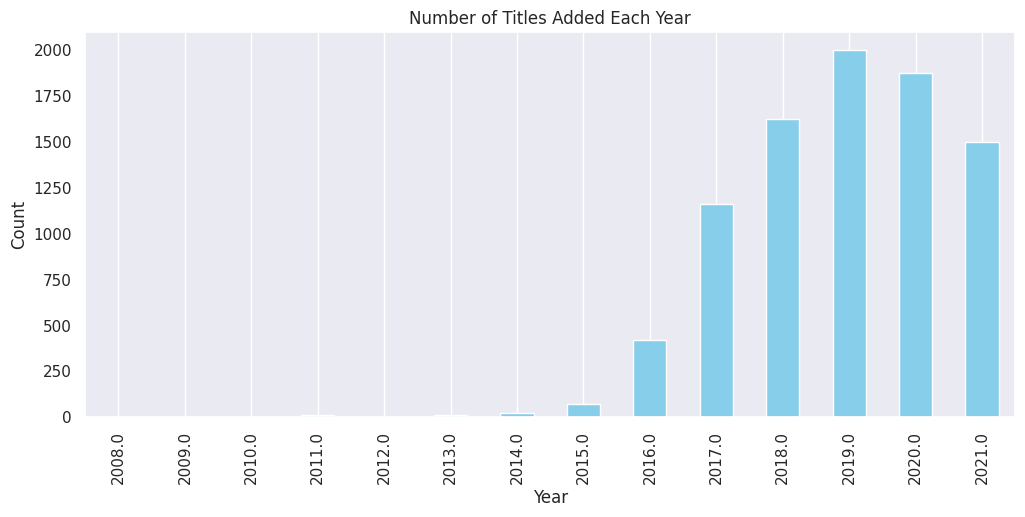


📈 Forecast (Simple Exponential Smoothing):


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



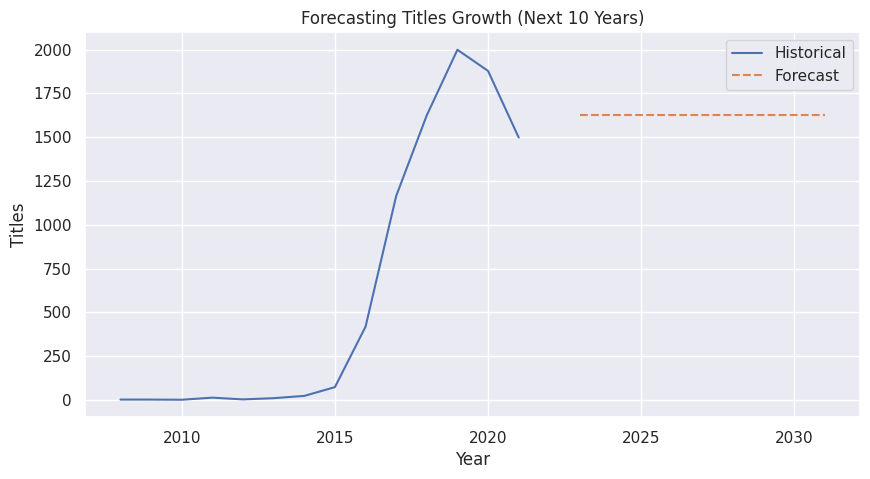


☁️ WordCloud from Descriptions:


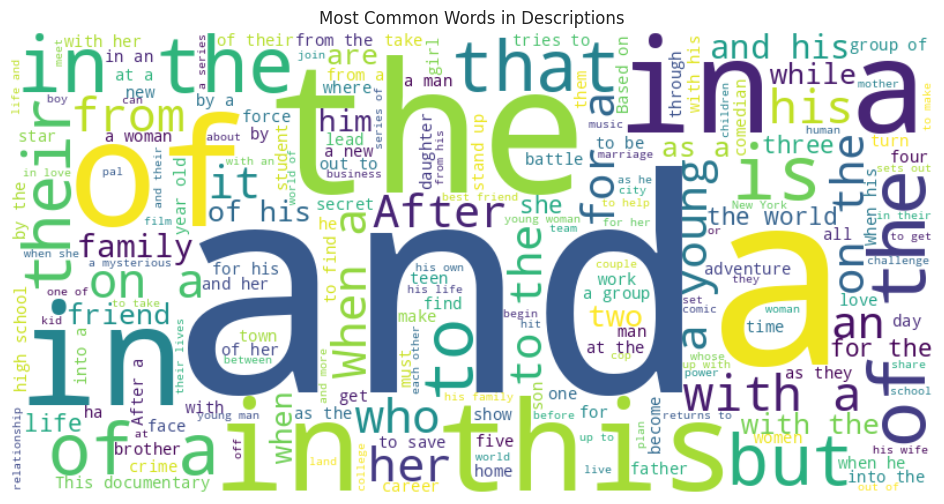


🔍 Top Keywords by TF-IDF:
life       668.874476
new        576.050257
young      565.785583
family     531.436297
world      498.203483
man        432.031167
love       409.576789
woman      387.068846
friends    386.899112
series     355.020576
dtype: float64


In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')
full_eda_dashboard(df)


# ✅ Netflix Titles Dataset – Complete EDA Project Summary Report

## 🎯 Objective
Perform detailed **Exploratory Data Analysis (EDA)** on the Netflix Titles dataset to extract meaningful insights, uncover hidden patterns, visualize trends, and predict future behavior — using only **Google Colab** with **no external software**.

---

## 📁 Dataset Used
**`netflix_titles.csv`**  
Source: [Kaggle Netflix Titles Dataset](https://www.kaggle.com/datasets/shivamb/netflix-shows)  
Contains metadata about TV Shows and Movies on Netflix including:
- Title, Director, Cast, Country, Date Added, Release Year
- Type (TV Show / Movie), Duration, Category, and Description

---

## ✅ Step-by-Step Modules Implemented

### 🔹 Module 1: Basic EDA & Visualization
- Dataset overview: shape, missing values, top rows
- Countplot of content types (TV Show vs Movie)
- Top 10 contributing countries
- Content added per year (bar chart)

---

### 🔹 Module 2: Forecasting Content Growth
- Converted `date_added` to extract `year_added`
- Built **Simple Exponential Smoothing** model
- Forecasted content growth up to year **2030**
- Visualized using matplotlib (Historical vs Forecasted)

---

### 🔹 Module 3: Genre Trend Over Time
- Extracted and exploded genres from `listed_in`
- Grouped by `year_added` and genre
- Created a **heatmap of top 10 genres over time**
- Highlighted changes in user/viewer content preference

---

### 🔹 Module 4: Clustering-Based Recommendation
- Extracted numerical features (duration, type, rating, genre)
- Applied **KMeans clustering**
- Used **t-SNE** for 2D cluster visualization
- Output clusters that could serve as content groups or recommendations

---

### 🔹 Module 5: Geo Visualization of Titles
- Handled multiple countries using `explode()`
- Counted titles per country
- Created a **choropleth map using Plotly** to show global content distribution

---

### 🔹 Module 6: NLP on Descriptions
- Used `description` field for text mining
- Generated **WordCloud** to visualize frequent keywords
- Applied **TF-IDF** to extract and rank top 10 keywords

---

### 🔹 Module 7: Final Dashboard Function (Google Colab Only)
One function: `full_eda_dashboard(df)` gives:
- Basic info & nulls
- Titles added per year (bar chart)
- Forecast up to 2030
- WordCloud from descriptions
- TF-IDF top keywords

✅ Works with **any compatible dataset**  
✅ Run inside **Google Colab** (no Streamlit or Flask needed)  
✅ One-click dashboard experience for reports or submission

---

## 💡 Additional Notes
- Everything is **modularized**: You can reuse the genre clustering, forecast, or NLP parts on any dataset
- Project is **portable** and can be shared as a `.ipynb` Colab file for submission or portfolio
- Each part follows best practices in real-world data science analysis

---

## ✅ Final Thoughts

> We’ve built a **complete end-to-end EDA project** that:
- Handles raw data
- Visualizes patterns
- Performs forecasting
- Uses NLP + clustering
- Is fully executable in Google Colab, **without any external apps or tools**

---
